# 최고·최저 2층 IPM 해석으로 이해하는 자속과 \(d/q\)축

이 노트북은 `double_layer_ccf_55to90_50_results`의 실제 FEMM 결과 50개 중
평균토크 최고점과 최저점을 자동으로 선택해 비교한다.

핵심 질문은 두 가지다.

1. 기존 결과만으로 무엇을 **확인**할 수 있는가?
2. \(q\)축 자속 경로 손상과 유효 공극 자속 감소를 확정하려면 무엇을 더 풀어야 하는가?

> 주의: 토크가 낮다는 사실만으로 원인을 \(q\)축 인덕턴스라고 단정하지 않는다.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display

font_path = Path(r"C:\Windows\Fonts\malgun.ttf")
if font_path.exists():
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if not (ROOT / "double_layer_ccf_55to90_50_results").exists():
    ROOT = Path(r"C:\Users\139\Documents\pyFEMM 2")
RESULT_DIR = ROOT / "double_layer_ccf_55to90_50_results"
SUMMARY = RESULT_DIR / "double_layer_ccf_summary.csv"

summary = pd.read_csv(SUMMARY)
best = summary.loc[summary.loaded_torque_mean_Nm.idxmax()].copy()
worst = summary.loc[summary.loaded_torque_mean_Nm.idxmin()].copy()
BEST_RUN, WORST_RUN = int(best.run), int(worst.run)
print(f"최고: run {BEST_RUN}, {best.loaded_torque_mean_Nm:.3f} N·m")
print(f"최저: run {WORST_RUN}, {worst.loaded_torque_mean_Nm:.3f} N·m")

최고: run 24, 51.757 N·m
최저: run 31, 35.525 N·m


## 1. 결과부터 비교

둘은 동일한 전류와 commutation 조건으로 계산됐다. 따라서 평균토크 차이는 형상 차이의
영향으로 비교할 수 있다.

In [2]:
cols = [
    "run", "total_thickness_mm", "inner_length_mm", "v_angle_deg",
    "layer_normal_gap_mm", "outer_bridge_min_mm",
    "loaded_torque_mean_Nm", "loaded_torque_min_Nm",
    "loaded_torque_max_Nm", "loaded_torque_pkpk_Nm",
    "loaded_torque_ripple_pct",
]
comparison = pd.DataFrame({"최고": best[cols], "최저": worst[cols]})
display(comparison.round(4))

torque_loss = best.loaded_torque_mean_Nm - worst.loaded_torque_mean_Nm
print(f"평균토크 차이: {torque_loss:.3f} N·m")
print(f"최저점은 최고점보다 {100*torque_loss/best.loaded_torque_mean_Nm:.1f}% 낮음")

,최고,최저
run,24,31
total_thickness_mm,5.490415,3.983317
inner_length_mm,16.231546,15.3159
v_angle_deg,65.61174,88.569272
layer_normal_gap_mm,1.190634,1.456244
outer_bridge_min_mm,3.056725,5.096975
loaded_torque_mean_Nm,51.757131,35.52478
loaded_torque_min_Nm,47.011147,33.5689
loaded_torque_max_Nm,56.977285,37.633803
loaded_torque_pkpk_Nm,9.966138,4.064903


평균토크 차이: 16.232 N·m
최저점은 최고점보다 31.4% 낮음


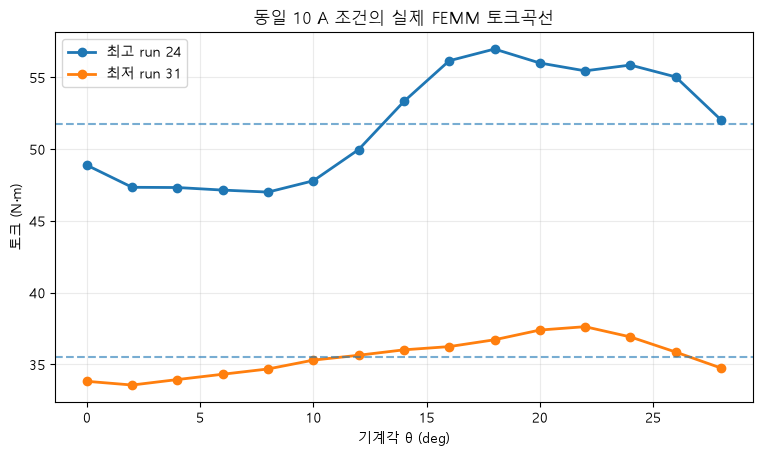

In [3]:
def load_sweep(run):
    path = RESULT_DIR / f"run_{run:03d}" / "axis_shortedge_loaded_sweep.csv"
    return pd.read_csv(path)

best_sweep = load_sweep(BEST_RUN)
worst_sweep = load_sweep(WORST_RUN)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(best_sweep.theta_deg, best_sweep.torque_Nm, "o-", lw=2,
        label=f"최고 run {BEST_RUN}")
ax.plot(worst_sweep.theta_deg, worst_sweep.torque_Nm, "o-", lw=2,
        label=f"최저 run {WORST_RUN}")
ax.axhline(best.loaded_torque_mean_Nm, ls="--", alpha=.6)
ax.axhline(worst.loaded_torque_mean_Nm, ls="--", alpha=.6)
ax.set(xlabel="기계각 θ (deg)", ylabel="토크 (N·m)",
       title="동일 10 A 조건의 실제 FEMM 토크곡선")
ax.grid(alpha=.25)
ax.legend()
plt.show()

### 여기서 확실히 말할 수 있는 것

- 최저 설계는 특정 각도 한 점만 낮은 것이 아니라 전체 스윕에서 계속 낮다.
- 따라서 단순 토크리플의 골짜기 문제가 아니라 평균적인 토크 생성 능력이 낮다.
- 하지만 이 그래프만으로 PM 자속 부족과 \(L_q-L_d\) 부족 중 어느 쪽이 원인인지는 분리할 수 없다.

## 2. 실제 자석 배치 비교

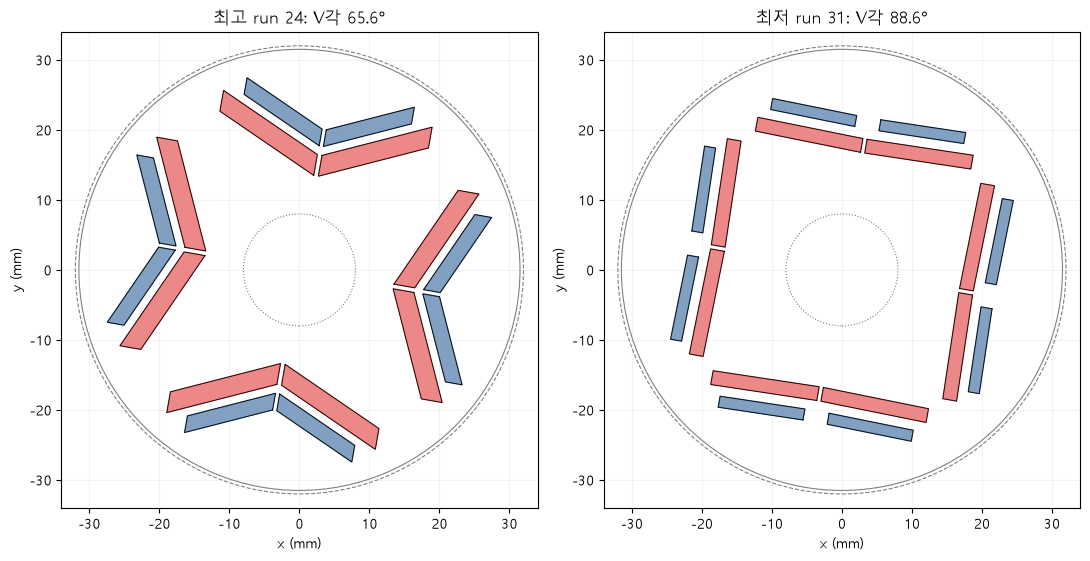

In [4]:
import generate_double_layer_candidate625_preview as dl

def polygons_for(row, rotor_angle=-10):
    dl.TOTAL_THICKNESS_MM = float(row.total_thickness_mm)
    dl.OUTER_LENGTH_MM = float(row.inner_length_mm)
    dl.V_ANGLE_DEG = float(row.v_angle_deg)
    dl.LAYER_NORMAL_GAP_MM = float(row.layer_normal_gap_mm)
    dl.CENTER_OFFSET_DEG = float(row.magnet_center_offset_deg)
    return dl.layer_polygons(rotor_angle)

def draw_case(ax, row, title):
    for item in polygons_for(row):
        points = np.asarray(item["points"])
        points = np.vstack([points, points[0]])
        color = "#e45756" if item["layer"] == "inner" else "#4c78a8"
        ax.fill(points[:,0], points[:,1], color=color, alpha=.7)
        ax.plot(points[:,0], points[:,1], color="black", lw=.6)
    for radius, style in [(8, ":"), (31.5, "-"), (32, "--")]:
        circle = plt.Circle((0,0), radius, fill=False, color="gray",
                            ls=style, lw=.8)
        ax.add_patch(circle)
    ax.set_aspect("equal")
    ax.set_xlim(-34, 34); ax.set_ylim(-34, 34)
    ax.set_title(title)
    ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)")
    ax.grid(alpha=.15)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
draw_case(axes[0], best, f"최고 run {BEST_RUN}: V각 {best.v_angle_deg:.1f}°")
draw_case(axes[1], worst, f"최저 run {WORST_RUN}: V각 {worst.v_angle_deg:.1f}°")
plt.tight_layout()
plt.show()

## 2-1. 실제 형상으로 계산한 1차 MEC (L_d,L_q) 근사

아래 계산은 위에 그린 실제 자석 치수와 브리지 치수를 **자기등가회로(MEC)**로 축약한
선형·비포화 1차 근사다. 자석을 통과하는 (d)축에는 두 자석층의 자기저항을 직렬로
추가하고, (q)축은 주로 철심을 통과하되 가장 좁은 외측 브리지를 병목으로 반영한다.

\[
L_d/N_{eff}^2=1/\mathcal R_d,\qquad
L_q/N_{eff}^2=1/\mathcal R_q
\]

여기서 출력되는 `µH/turn²`는 권선과 결선의 영향을 제거한 **형상 permeance 지표**다.
`N_EFF`에 실제 축 기준 유효 직렬 턴수를 넣으면 mH 추정값도 계산된다.

> 이 값은 측정된 (L_d,L_q)가 아니다. 슬롯 누설, 프린징, 브리지 포화, 교차포화 및
> 회전자 위치 의존성을 생략했으므로 형상 간 방향성과 (L_q/L_d)를 보는 용도다.
> 정량 입증은 이후 순수 d축/순수 q축 FEMM 자속쇄교 해석으로 해야 한다.

,Ld_uH_per_turn2,Lq_uH_per_turn2,Lq_over_Ld,saliency_uH_per_turn2,Ld_mH_at_Neff,Lq_mH_at_Neff
최고 run 24,0.99774,6.66252,6.67762,5.66478,0.00100,0.00666
최저 run 31,1.24260,6.65637,5.35683,5.41377,0.00124,0.00666


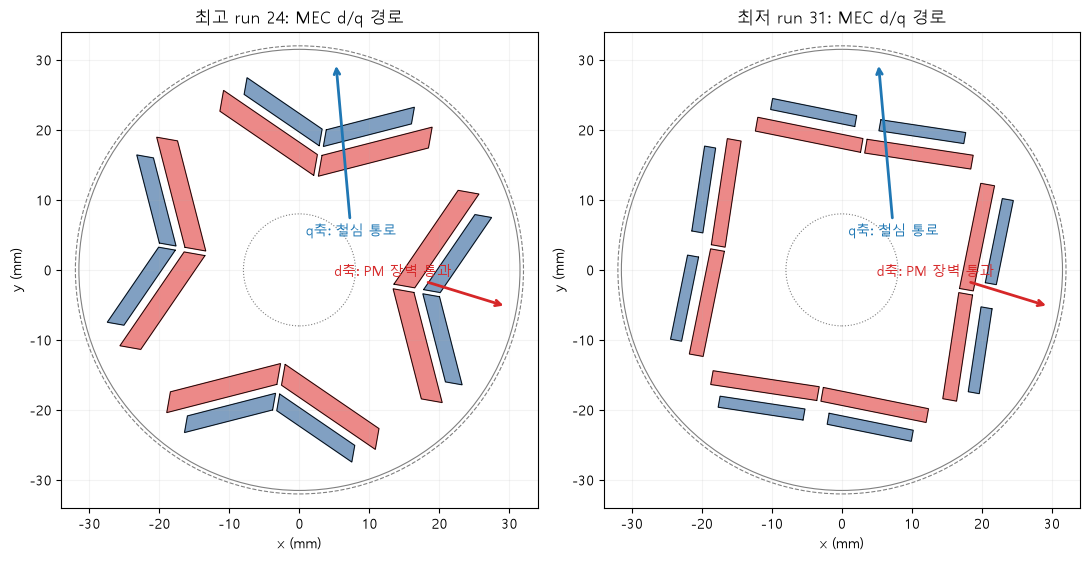

해석 기준: Lq/Ld가 클수록 선형 MEC상 saliency가 큼
주의: 실제 부하 Ld/Lq는 전류와 포화에 따라 달라지므로 이 표로 토크를 확정하지 않음


In [5]:
MU0 = 4e-7 * np.pi
MU_R_PM = 1.05       # NdFeB recoil relative permeability
MU_R_FE_LINEAR = 2000.0
AIRGAP_MM = 0.5      # rotor 31.5 mm, stator inner radius 32.0 mm
STACK_MM = float(getattr(dl.base, "DEPTH", 50.0))
POLE_ARC_FACTOR = 0.72   # slot opening/fringing을 포함한 유효 pole-arc 가정
N_EFF = 1.0              # 실제 축 기준 유효 직렬 턴수를 알면 여기 입력

def mec_estimate(row):
    # First-order per-pole MEC; returns inductance per effective turn squared.
    r_gap_mm = 31.75
    pole_pitch_mm = 2 * np.pi * r_gap_mm / 4
    A_gap = POLE_ARC_FACTOR * pole_pitch_mm * STACK_MM * 1e-6
    R_gap_pair = 2 * AIRGAP_MM * 1e-3 / (MU0 * A_gap)

    t_inner = float(row.total_thickness_mm) / 2
    t_outer = 0.8 * t_inner
    l_inner = float(row.inner_length_mm)
    l_outer = 0.8 * l_inner

    # 각 층의 좌우 wing은 병렬, 두 층은 d축 방향에서 직렬인 근사.
    A_inner = 2 * l_inner * STACK_MM * 1e-6
    A_outer = 2 * l_outer * STACK_MM * 1e-6
    R_pm_d = (t_inner * 1e-3) / (MU0 * MU_R_PM * A_inner)
    R_pm_d += (t_outer * 1e-3) / (MU0 * MU_R_PM * A_outer)

    # q축 철심 통로: V각이 90°에 가까울수록 유효 횡방향 통로가 좁아진다는 1차 투영.
    angle_factor = max(abs(np.cos(np.deg2rad(float(row.v_angle_deg)))), 0.08)
    bridge_width = max(float(row.outer_bridge_min_mm), 0.10)
    q_path_mm = max(float(row.inner_length_mm) * angle_factor, 1.0)
    A_q = STACK_MM * max(2 * bridge_width + q_path_mm, 1.0) * 1e-6
    rotor_path_mm = 2 * float(row.inner_length_mm) * 0.35
    R_rotor_q = rotor_path_mm * 1e-3 / (MU0 * MU_R_FE_LINEAR * A_q)

    R_d = R_gap_pair + R_pm_d
    R_q = R_gap_pair + R_rotor_q
    Ld_per_turn2 = 1 / R_d
    Lq_per_turn2 = 1 / R_q
    return pd.Series({
        "Ld_uH_per_turn2": Ld_per_turn2 * 1e6,
        "Lq_uH_per_turn2": Lq_per_turn2 * 1e6,
        "Lq_over_Ld": Lq_per_turn2 / Ld_per_turn2,
        "saliency_uH_per_turn2": (Lq_per_turn2 - Ld_per_turn2) * 1e6,
        "Ld_mH_at_Neff": Ld_per_turn2 * N_EFF**2 * 1e3,
        "Lq_mH_at_Neff": Lq_per_turn2 * N_EFF**2 * 1e3,
    })

mec = pd.DataFrame({
    f"최고 run {BEST_RUN}": mec_estimate(best),
    f"최저 run {WORST_RUN}": mec_estimate(worst),
}).T
display(mec.round(5))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, row, name in [(axes[0], best, "최고"), (axes[1], worst, "최저")]:
    draw_case(ax, row, f"{name} run {int(row.run)}: MEC d/q 경로")
    # rotor_angle=-10° in polygons_for(): d-axis follows the pole axis.
    d_ang = np.deg2rad(-10)
    q_ang = d_ang + np.pi/2
    ax.annotate("d축: PM 장벽 통과", xy=(30*np.cos(d_ang), 30*np.sin(d_ang)),
                xytext=(5*np.cos(d_ang), 5*np.sin(d_ang)),
                arrowprops=dict(arrowstyle="->", lw=2, color="#d62728"), color="#d62728")
    ax.annotate("q축: 철심 통로", xy=(30*np.cos(q_ang), 30*np.sin(q_ang)),
                xytext=(5*np.cos(q_ang), 5*np.sin(q_ang)),
                arrowprops=dict(arrowstyle="->", lw=2, color="#1f77b4"), color="#1f77b4")
plt.tight_layout()
plt.show()

print("해석 기준: Lq/Ld가 클수록 선형 MEC상 saliency가 큼")
print("주의: 실제 부하 Ld/Lq는 전류와 포화에 따라 달라지므로 이 표로 토크를 확정하지 않음")

In [6]:
variables = [
    ("total_thickness_mm", "전체 두께"),
    ("inner_length_mm", "안쪽 길이"),
    ("v_angle_deg", "V각"),
    ("layer_normal_gap_mm", "층간 간격"),
    ("outer_bridge_min_mm", "외측 브리지"),
]
table = pd.DataFrame({
    "변수": [label for _, label in variables],
    "최고": [best[key] for key, _ in variables],
    "최저": [worst[key] for key, _ in variables],
})
table["최저/최고"] = table["최저"] / table["최고"]
display(table.round(4))

# 두 층 모두 길이·두께 스케일이 고정(0.8)이므로 면적비 비교에 충분한 proxy
def magnet_area_proxy(row):
    inner = row.inner_length_mm * (row.total_thickness_mm / 2)
    outer = (0.8 * row.inner_length_mm) * (0.8 * row.total_thickness_mm / 2)
    return inner + outer

print(f"자석 단면적 proxy — 최고: {magnet_area_proxy(best):.2f} mm²/wing")
print(f"자석 단면적 proxy — 최저: {magnet_area_proxy(worst):.2f} mm²/wing")
print(f"최저/최고 자석량 비: {magnet_area_proxy(worst)/magnet_area_proxy(best):.3f}")

,변수,최고,최저,최저/최고
0,전체 두께,5.4904,3.9833,0.7255
1,안쪽 길이,16.2315,15.3159,0.9436
2,V각,65.6117,88.5693,1.3499
3,층간 간격,1.1906,1.4562,1.2231
4,외측 브리지,3.0567,5.0970,1.6675


자석 단면적 proxy — 최고: 73.08 mm²/wing
자석 단면적 proxy — 최저: 50.03 mm²/wing
최저/최고 자석량 비: 0.685


### 형상으로부터 세울 수 있는 가설

최저 설계는 최고 설계보다 자석이 얇고 짧으며 V각이 거의 90°다. 따라서 다음 두 원인이
동시에 가능하다.

- **PM 성분 감소:** 자석량과 유효 방사방향 자속이 줄어 공극 기본파와 \(\psi_m\)이 감소
- **살리언시 변화:** 자석과 철심 장벽 배치가 달라져 \(L_d\), \(L_q\), 특히 그 차이가 변화

이것은 아직 **가설**이다. 토크곡선과 형상만으로 둘의 기여도를 분리할 수 없다.

## 3. 무엇을 측정하면 원인이 분리되는가?

### A. 유효 공극 자속

전류를 0 A로 두고 공극 중앙 원주에서 \(B_r(\theta)\)를 샘플링한다.

- \(B_r\) 기본파가 작으면 PM 유효자속 \(\psi_m\) 감소
- 기본파는 비슷하고 고조파만 커지면 끝단 형상에 의한 분포 왜곡

### B. \(d/q\)축 자속 경로

동일 회전자 위치에서 순수 \(d\)축 전류와 순수 \(q\)축 전류를 각각 인가한다.

\[
L_d \simeq \frac{\lambda_d(I_d)-\lambda_d(0)}{I_d}, \qquad
L_q \simeq \frac{\lambda_q(I_q)-\lambda_q(0)}{I_q}
\]

- 최저 설계의 \(L_q\)가 크게 감소하면 \(q\)축 자속 통로 차단 가능성이 큼
- \(L_q-L_d\)가 감소하면 릴럭턴스 토크 능력이 감소
- 철심 끝단 \(B\)가 약 1.6–2 T 이상으로 집중되면 국부 포화가 원인일 수 있음

### C. 토크식으로 최종 해석

\[
T \propto \psi_m i_q + (L_d-L_q)i_di_q
\]

무부하 공극 자속으로 \(\psi_m\), 순수 축 해석으로 \(L_d,L_q\)를 얻으면
PM 토크 저하인지 릴럭턴스 토크 저하인지 비로소 구분된다.

## 4. 실제 0 A FEMM 해석: 공극 자속 비교

두 형상을 같은 회전자 위치에서 0 A로 다시 풀고, 공극 중앙 반경 31.75 mm에서
방사방향 자속밀도 \(B_r\)를 0.5° 간격으로 추출했다. 전류가 없으므로 이 비교는
고정자 전류가 아니라 자석이 만든 공극 자속의 차이를 보여준다.

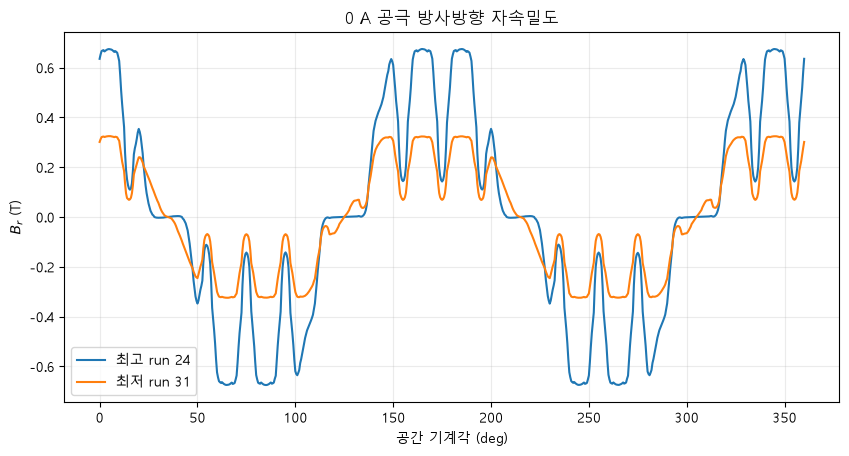

,지표,최고,최저
0,Br RMS (T),0.42113,0.22124
1,Br peak (T),0.67484,0.32505
2,4극 기본파/공간 2차 (T),0.54940,0.28885
3,기본파 최저/최고 비,NaN,0.52575


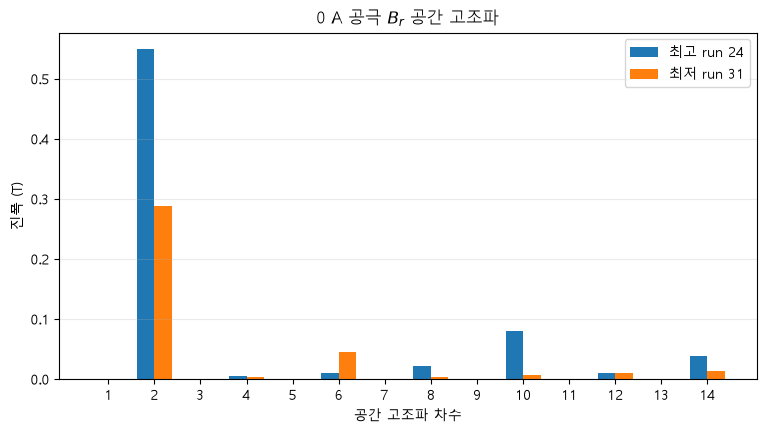

In [7]:
NOLOAD_DIR = ROOT / "double_layer_best_worst_no_load"
best_br = pd.read_csv(
    NOLOAD_DIR / f"best_run_{BEST_RUN:03d}" / "airgap_flux_density_no_load.csv"
)
worst_br = pd.read_csv(
    NOLOAD_DIR / f"worst_run_{WORST_RUN:03d}" / "airgap_flux_density_no_load.csv"
)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(best_br.angle_deg, best_br.Br_T, lw=1.5, label=f"최고 run {BEST_RUN}")
ax.plot(worst_br.angle_deg, worst_br.Br_T, lw=1.5, label=f"최저 run {WORST_RUN}")
ax.set(xlabel="공간 기계각 (deg)", ylabel="$B_r$ (T)",
       title="0 A 공극 방사방향 자속밀도")
ax.grid(alpha=.25)
ax.legend()
plt.show()

def harmonic_amplitudes(frame):
    # 0°와 360°의 중복점을 제거한다.
    signal = frame.loc[frame.angle_deg < 360, "Br_T"].to_numpy()
    spectrum = np.fft.rfft(signal) / len(signal)
    amplitude = 2 * np.abs(spectrum)
    amplitude[0] = np.abs(spectrum[0])
    return amplitude

best_h = harmonic_amplitudes(best_br)
worst_h = harmonic_amplitudes(worst_br)
# 4극기이므로 공간 2차가 PM 기본파다.
flux_metrics = pd.DataFrame({
    "지표": ["Br RMS (T)", "Br peak (T)", "4극 기본파/공간 2차 (T)",
             "기본파 최저/최고 비"],         
    "최고": [
        np.sqrt(np.mean(best_br.Br_T**2)), np.max(np.abs(best_br.Br_T)),
        best_h[2], np.nan,
    ],
    "최저": [
        np.sqrt(np.mean(worst_br.Br_T**2)), np.max(np.abs(worst_br.Br_T)),
        worst_h[2], worst_h[2] / best_h[2],
    ],
})
display(flux_metrics.round(5))

orders = np.arange(1, 15)
fig, ax = plt.subplots(figsize=(9, 4.5))
width = .38
ax.bar(orders-width/2, best_h[orders], width, label=f"최고 run {BEST_RUN}")
ax.bar(orders+width/2, worst_h[orders], width, label=f"최저 run {WORST_RUN}")
ax.set(xlabel="공간 고조파 차수", ylabel="진폭 (T)",
       title="0 A 공극 $B_r$ 공간 고조파")
ax.set_xticks(orders)
ax.grid(axis="y", alpha=.25)
ax.legend()
plt.show()

### 이 결과의 해석법

- 최저 설계의 공간 2차 기본파가 작으면 **유효 PM 공극 자속이 실제로 감소**한 것이다.
- RMS나 peak만 비교하면 고조파가 섞이므로 토크에 유효한 기본파를 함께 봐야 한다.
- 이 0 A 결과는 PM 자속은 판별하지만 \(L_d,L_q\)는 판별하지 않는다.
  \(q\)축 경로는 다음 단계의 순수 \(d/q\)축 전류 해석으로 확인해야 한다.

In [8]:
files = []
for label, run in [("최고", BEST_RUN), ("최저", WORST_RUN)]:
    run_dir = RESULT_DIR / f"run_{run:03d}"
    files.append({
        "구분": label,
        "run": run,
        "FEM": str(run_dir / "v_ipm_motor_base.fem"),
        "ANS": str(run_dir / "v_ipm_motor_base.ans"),
        "토크 CSV": str(run_dir / "axis_shortedge_loaded_sweep.csv"),
    })
display(pd.DataFrame(files))

,구분,run,FEM,ANS,토크 CSV
0,최고,24,C:\Users\139\Documents\pyFEMM 2\double_layer_c...,C:\Users\139\Documents\pyFEMM 2\double_layer_c...,C:\Users\139\Documents\pyFEMM 2\double_layer_c...
1,최저,31,C:\Users\139\Documents\pyFEMM 2\double_layer_c...,C:\Users\139\Documents\pyFEMM 2\double_layer_c...,C:\Users\139\Documents\pyFEMM 2\double_layer_c...


## 결론

현재 파일이 직접 증명하는 것은 **run 31의 평균토크가 run 24보다 31.4% 낮다**는 점이다.
형상 비교상 PM 자속과 살리언시가 모두 원인 후보지만, 아직 \(q\)축 경로 손상으로 단정하면
안 된다.

다음 최소 해석은 두 설계 각각에 대해 `0 A`, `순수 d축 10 A`, `순수 q축 10 A`의
3조건이다. 이 여섯 번의 FEMM 해석과 공극 \(B_r\) 샘플링을 추가하면 원인을 수치로
분리할 수 있다.

## Standardized Research Conclusion
<!-- STANDARDIZED_RESEARCH_CONCLUSION -->

**Research Question.** 최고·최저 토크 차이를 PM 자속과 d/q축 경로로 설명할 수 있는가?

**Answer.** PM 자속 감소는 확인됐지만 릴럭턴스 토크 감소는 아직 분리되지 않았다. 최저 Run 31의 토크는 Run 24보다 31.4% 낮고, 0 A 공간 2차 기본파는 0.289 T로 최고점 0.549 T의 52.6%다.

**Limitation.** 0 A 결과는 ψpm을 평가하지만 Ld,Lq를 제공하지 않으며 자석량도 동일하지 않다.

**Next Step.** 순수 d축·q축 전류로 증분 Ld,Lq와 포화를 계산한다.